## Multiple Input Graph
实现更多的输入：   
Objectives:
1) Define a more complex AgentState    
2) Create a processing node（处理节点） that performs operations on list data（对数据列表进行操作）
3) Set up（建立）a LangGraph that processes and outputs computed results
4) Invoke the graph with structured inputs and retrieve outputs    （启动 与检索输出）
Main Goal: learn how to handle multiple inputs


### 理解
1) AgentState: 定义更复杂的记忆档案袋 数据类型——string+list（int等）
2) processing node :能处理列表数据的节点：节点能读取传入的多个数据、还要学会操作列表、
3) LangGraph 搭建图并输出计算结果：
4) Invoke graph ：用结构化输入启动并获取输出；

In [1]:
from typing import TypedDict,List
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    values:List[int]   #列表+且每一个元素都是整数；
    name: str
    result:str  #类型提示：定义变量以及固定类别、字典的键名对应值的类型；
#代码解析：
#1）使用类别字典定义好 State、设置好变量以及固定对应的变量！
#2）为什么选用这个TypedDict作为State的载体呢？----
#3）字典的优势：契合JSON 与记忆存储！是最容易直接无损转换成JSON格式的数据结构、天生为了数据流转而生的；
#4）TypedDict 可以强制所有的节点必须遵循统一的命名和类型规范；
#5) 契合LangGraph 的图更新——在LangGraph 中 节点之间的信息传递不是覆盖，而是更新，字典的update 机制（向字典中追加或修改一个键对值）契合这种状态流转的机制；

In [ ]:
def process_values(state: AgentState) -> AgentState:
    """this function handle multiple different inputs """

    state["result"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    return state
# 代码解析：
#1）理解节点工作的三部曲——拆包——加工——重新打包
#2）def ：定义一个工具、process_values是我们这个工具节点得名称、state: AgentState、可以理解为进料口、
#3）拆包读取——当这个函数被触发时、定义好的Agentstate 字典被塞进state 这个参数中；具体读取了state['name']、state['values']
#4）加工：首先是：对提取出来的values 尽心sum；其次就是 f-string 魔法；这是python 中处理字符串拼接的神器，就像一个空白模板，吧提取出来的具体字节以及处理好的数值无缝插入指定的位置；
#5）重新打包：将更新好的state["result"] 退回还给系统；
#6）-> AgentState:  是一个很好的防错机制——确保return还是state（AgentState）


In [ ]:
graph = StateGraph(AgentState) #首先：向系统申报图纸、同样的 传入参数 Agentstate

graph.add_node("processor",process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()
#代码解析
#1) 第三部分——“Graph”、"排兵布阵" 将散落的零件，组装成一条自动化运转的流水线。
#2）StateGraph 是langgraph 框架中最核心的类、他的本职工作就是用来管理状态流转的“有向图”
#3) graph =  配置好的图纸实例化，赋值给graph、
#4）graph.add_node 向图纸中添加节点、他需要传入2个关键参数、A）processor、字符串起的一个ID、B)process_values 具体的函数对象、是机器的内部核心、不能带括号、因为我们只是放入，不是立即运行；
#5）连接管线——在LangGraph中，信息的流转是有绝对方向的，这叫有向图；
#6）.set_entry_point——你在图的内部创建了一个虚拟的起点（通常系统底层叫它 __start__）。这句话的意思是，只要外界通过 .invoke() 往系统里投递了初始物料，第一站绝对强制送往挂着 "processor" 门牌号的机器。
#7) .set_finish_point——这等同于在 "processor" 这台机器的屁股后面接了一根直通厂房大门外的管道。只要这台机器一处理完数据（执行了 return state），不用再往下找其他机器了，直接宣告整个流水线任务结束（走向 __end__），并把最终的公文包吐出给用户。
#8）app = graph.compile() ！这是最神奇，也是区分LangGraph 与普通Python 脚本最关键的一步，前面4行代码只是在修改配置列表；
#9）.compile()：1、拓扑检查、2：状态冻结与封装一旦检查全部合格，系统就会把这张图纸“冻结”，编译生成一个拥有独立内存、随时可以接收外界指令的可执行应用（Runnable Object）。

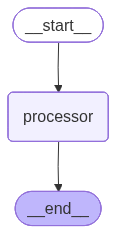

In [ ]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))
# 代码解析：
#app.get_graph 把这个大楼的骨架给提取出来
# .draw_mermaid_png 是把骨架交给一个叫 Mermaid 的排版引擎，画成一张 PNG 图片。
# 无论你的图有多复杂，有几十个节点还是几百条连线，这两行代码永远都不变，它会忠实地把你亲手搭建的“工作流”清清楚楚地画出来。

In [ ]:
answer = app.invoke({"values":[1,2,3,4],"name":"chenhao"})   # not graph.invoke() 因为状态图没有属性 还没有编译好compile；
print(answer)
# 代码解析：投料生产与验收 invoke
#1）app.invoke 就是启动这个我们已经通过/compiler好的app 、
#2）括号里的字典 ：{"values":[1,2,3,4],"name":"chenhao"} 就是第一批“原料”——初始状态；
#3）！！你会发现这里的字典与我们一开始设置的 变量不是完全一样的——少了一个result 这就是 LangGraph 极其智能的**“缺省宽容机制”**。
#4） 

{'name': 'chenhao', 'values': [1, 2, 3, 4], 'result': 'Hi there chenhao! Your sum = 10'}
